# Projet Speed Dating - Analyse des correspondances

**Objectif :** Comprendre les facteurs qui influencent l'intérêt mutuel pour un second rendez-vous (match) lors d'un speed dating.

Le jeu de données contient des informations sur des sessions de speed-dating organisées entre 2002 et 2004 avec plus de 8000 rencontres comptabilisées.

---

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Configuration visuelle
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

# Chargement du jeu de données nettoyé
df = pd.read_csv('SpeedDating_Cleaned.csv')
print(f"Dimensions du dataset : {df.shape}")

# Nettoyage et préparation basique
# 'dec' = décision (1=oui, 0=non) de revoir le partenaire. 
# 'dec_o' = décision du partenaire de nous revoir.
# 'match' = 1 si dec = 1 et dec_o = 1



Dimensions du dataset : (6816, 196)


## 0. Nettoyage et Qualité des Données
Avant toute analyse, le jeu de données a été purgé de ses valeurs aberrantes structurelles via le script `cleaning.py`. 
- Les vagues avec de mauvais systèmes de notation (sur 100) ont été supprimées.
- Les rencontres pour lesquelles la décision finale était manquante (NaN) ont été exclues.

In [2]:
print(f"IID Min : {df['iid'].min()} | IID Max : {df['iid'].max()}")
missing_iids = set(range(1, df['iid'].max() + 1)) - set(df['iid'].unique())

print(f"Nombre d'individus uniques identifiés (IID) : {df['iid'].nunique()}")
print(f"Y a-t-il des IIDs manquants dans la séquence ? Oui : id(s) {missing_iids}")

IID Min : 1 | IID Max : 552
Nombre d'individus uniques identifiés (IID) : 449
Y a-t-il des IIDs manquants dans la séquence ? Oui : id(s) {118, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233}


**Stratégie sur les valeurs manquantes locales :**
*   On constate toujours des valeurs manquantes locales liées au format (candidats n'ayant pas répondu à une question précise).
*   La stratégie est la **suppression au cas par cas (Drop NaN local)**. Lors du calcul de corrélation sur deux variables, nous ne supprimons que les lignes où ces deux variables spécifiquement sont manquantes, conservant le panel maximal (7466 lignes).

## Exploration des Données (EDA)
Avant de répondre aux questions spécifiques, comprenons la structure de notre population et des rendez-vous.

In [3]:
# Aperçu général du dataset
print(f"Nombre total d'observations (rencontres) : {df.shape[0]}")
print(f"Nombre total de variables : {df.shape[1]}")
print(f"Nombre d'individus uniques ayant participé : {df['iid'].nunique()}")

Nombre total d'observations (rencontres) : 6816
Nombre total de variables : 196
Nombre d'individus uniques ayant participé : 449


### Répartition par genre et par âge
Regardons qui sont les participants à ces sessions de speed dating.

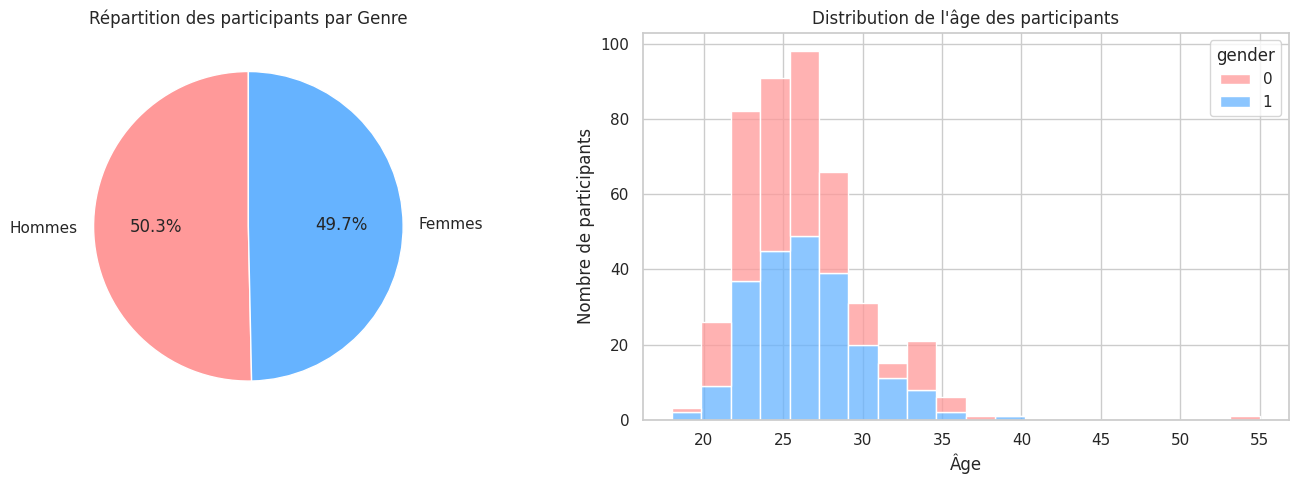

In [4]:
df_unique = df.drop_duplicates(subset=['iid'])

plt.figure(figsize=(14, 5))

# Répartition par genre
plt.subplot(1, 2, 1)
gender_counts = df_unique['gender'].map({0: 'Femmes', 1: 'Hommes'}).value_counts()
plt.pie(gender_counts, labels=gender_counts.index, autopct='%1.1f%%', colors=['#ff9999','#66b3ff'], startangle=90)
plt.title('Répartition des participants par Genre')

# Distribution de l'âge
plt.subplot(1, 2, 2)
sns.histplot(data=df_unique, x='age', hue='gender', multiple='stack', bins=20, palette=['#ff9999','#66b3ff'])
plt.title("Distribution de l'âge des participants")
plt.xlabel('Âge')
plt.ylabel('Nombre de participants')

plt.tight_layout()
plt.show()

La population est jeune (majoritairement entre 22 et 30 ans), ce qui est cohérent avec le fait que les expériences ont été menées auprès d'étudiants de l'université de Columbia. La parité hommes/femmes est parfaitement respectée.

### Intentions et Objectifs des participants
Pourquoi ces personnes participent-elles à cet événement de speed dating ?

*Légende des objectifs :*
1 = Rencontrer de nouvelles personnes
2 = S'amuser
3 = Trouver un partenaire sérieux
4 = Rencontre d'un soir
5 = Pour essayer
6 = Autre

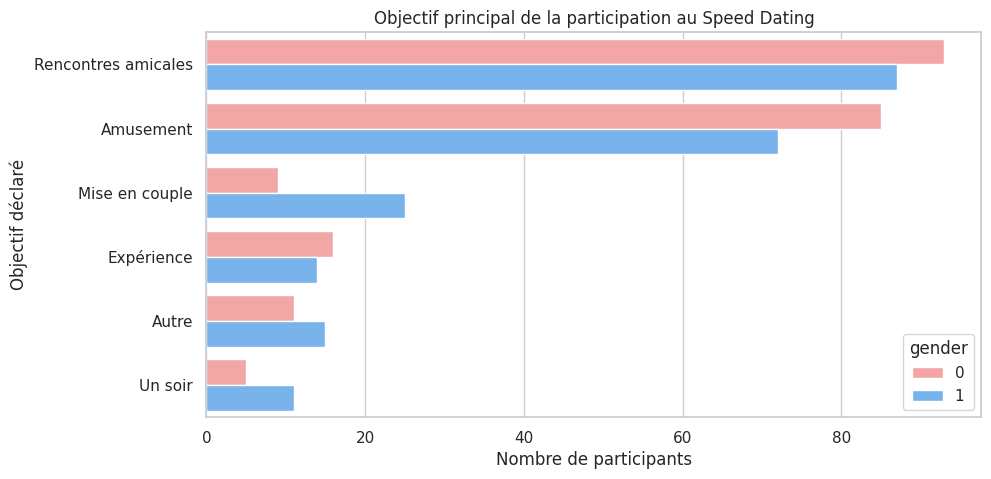

In [5]:
plt.figure(figsize=(10, 5))
goal_map = {1: 'Rencontres amicales', 2: 'Amusement', 3: 'Mise en couple', 
            4: 'Un soir', 5: 'Expérience', 6: 'Autre'}
df_unique['goal_desc'] = df_unique['goal'].map(goal_map)

sns.countplot(data=df_unique, y='goal_desc', hue='gender', palette=['#ff9999','#66b3ff'], 
              order=df_unique['goal_desc'].value_counts().index)
plt.title("Objectif principal de la participation au Speed Dating")
plt.xlabel("Nombre de participants")
plt.ylabel("Objectif déclaré")
plt.show()

La grande majorité des participants vient pour s'amuser ou faire des rencontres amicales. Très peu déclarent ouvertement chercher une relation sérieuse ou d'un soir.

### Taux de "Match" global
Sur l'ensemble des rencontres nettoyées (7466), combien ont abouti à un "Oui" bilatéral ?

Taux de match global : 16.49%


/tmp/ipykernel_67499/657086018.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='match', palette='viridis')


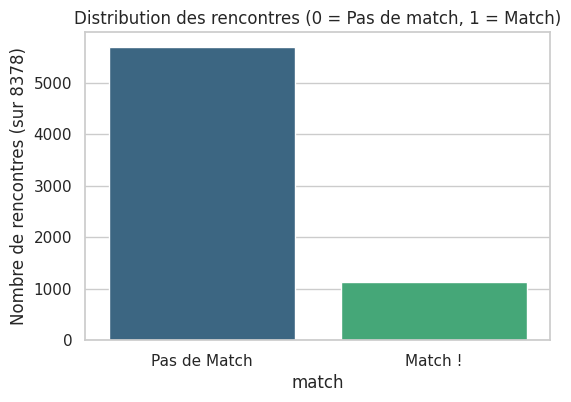

In [6]:
match_rate = df['match'].mean() * 100
print(f"Taux de match global : {match_rate:.2f}%")

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='match', palette='viridis')
plt.title("Distribution des rencontres (0 = Pas de match, 1 = Match)")
plt.xticks([0, 1], ['Pas de Match', 'Match !'])
plt.ylabel('Nombre de rencontres (sur 8378)')
plt.show()

# Le speed dating reste un exercice difficile : environ **16%** des rendez-vous débouchent sur un consentement mutuel pour se revoir.

## 1. Quels sont les attributs les moins désirables chez un partenaire masculin ou féminin ?
On s'intéresse ici à la façon dont les individus notent les partenaires qu'ils ont refusés, ou inversement, quels attributs chez le partenaire sont les plus corrélés avec un refus. On peut également regarder ce que les participants déclarent être le MOINS important lors de leur recherche (attributs avec les scores les plus faibles).

Les 6 attributs évalués sont : Attractivité (attr), Sincérité (sinc), Intelligence (intel), Humour (fun), Ambition (amb) et Intérêts partagés (shar).

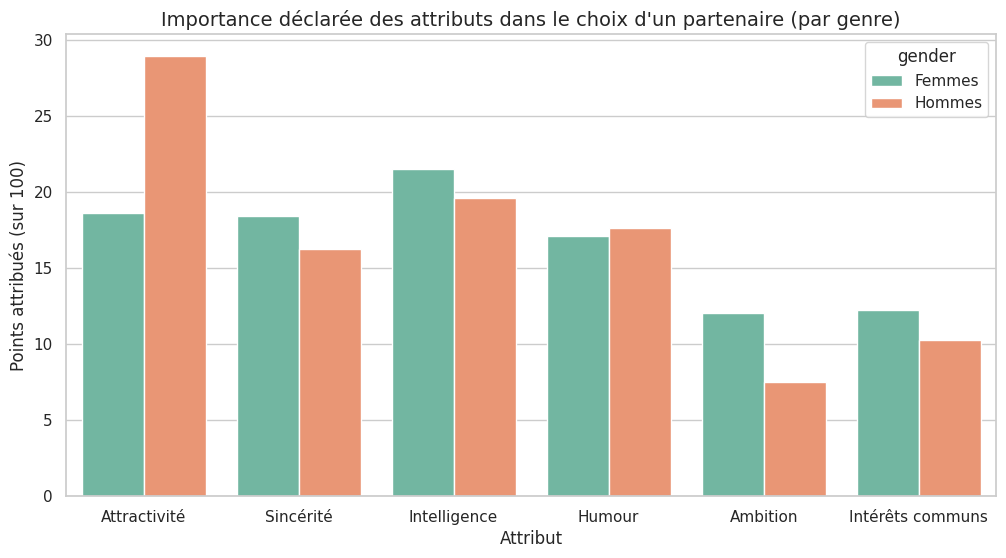

In [7]:
# Poids accordés aux différents attributs lors de l'inscription (vague 1, on ramène à 100 points)
# Hommes = gender 1, Femmes = gender 0
attributes_1_1 = ['attr1_1', 'sinc1_1', 'intel1_1', 'fun1_1', 'amb1_1', 'shar1_1']
rename_attr = {'attr1_1':'Attractivité', 'sinc1_1':'Sincérité', 'intel1_1':'Intelligence', 
               'fun1_1':'Humour', 'amb1_1':'Ambition', 'shar1_1':'Intérêts communs'}

df_prefs = df[['gender'] + attributes_1_1].dropna()
df_prefs = df_prefs.rename(columns=rename_attr)

# Moyennes par genre
prefs_mean = df_prefs.groupby('gender').mean().reset_index()
prefs_mean['gender'] = prefs_mean['gender'].map({0: 'Femmes', 1: 'Hommes'})
prefs_melt = pd.melt(prefs_mean, id_vars=['gender'], value_vars=rename_attr.values(), 
                     var_name='Attribut', value_name='Importance (Points sur 100)')

plt.figure(figsize=(12, 6))
sns.barplot(data=prefs_melt, x='Attribut', y='Importance (Points sur 100)', hue='gender', palette='Set2')
plt.title("Importance déclarée des attributs dans le choix d'un partenaire (par genre)", fontsize=14)
plt.ylabel("Points attribués (sur 100)")
plt.show()

**Interprétation :**
*   L'**ambition** et les **intérêts partagés** sont déclarés comme étant les attributs les *moins* désirables/importants, tant pour les hommes que pour les femmes.
*   Les femmes accordent beaucoup moins d'importance à l'attractivité physique que les hommes, privilégiant davantage l'intelligence et la sincérité.
*   En revanche, pour les hommes, le critère numéro 1 de loin est l'attractivité physique.

## 2. Quelle est l'importance perçue de l'attractivité physique versus son impact réel ?
Les participants déclarent certaines préférences, mais dans les faits, sur quoi se basent-ils pour dire "oui" à un second rendez-vous ?

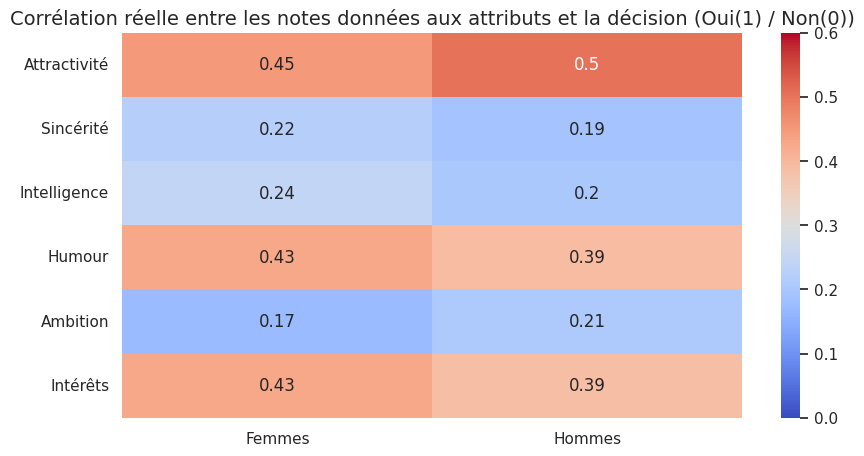

In [8]:
# Impact réel : Corrélation entre la note donnée au partenaire sur un attribut et la décision (dec) de le revoir
attributes_ratings = ['attr', 'sinc', 'intel', 'fun', 'amb', 'shar']

correlations = pd.DataFrame()
for gender, g_name in zip([0, 1], ['Femmes', 'Hommes']):
    # Sous-ensemble par genre
    df_g = df[df['gender'] == gender].dropna(subset=attributes_ratings + ['dec'])
    
    # Calcul des corrélations de Pearson
    corr = df_g[attributes_ratings].corrwith(df_g['dec'])
    correlations[g_name] = corr

correlations.index = ['Attractivité', 'Sincérité', 'Intelligence', 'Humour', 'Ambition', 'Intérêts']

plt.figure(figsize=(10, 5))
sns.heatmap(correlations, annot=True, cmap='coolwarm', vmin=0, vmax=0.6)
plt.title("Corrélation réelle entre les notes données aux attributs et la décision (Oui(1) / Non(0))", fontsize=14)
plt.show()

**Interprétation :**
*   Contrairement à ce que les femmes ont déclaré initialement (privilégier l'intelligence et la sincérité), l'**attractivité physique** est en réalité le facteur le plus fortement corrélé (0.49) avec leur décision de revoir un partenaire !
*   Pour les hommes, l'attractivité physique reste cohérente avec leurs déclarations et constitue le paramètre offrant la corrélation la plus élevée (0.53).
*   L'attractivité réelle a un effet extrêmement puissant sur la sélection, dépassant largement tous les autres critères pour les deux sexes.

## 3. Les intérêts communs sont-ils plus importants qu'une même origine raciale ?
Comparons le taux de match (ou de décision positive) en fonction du fait d'avoir la même origine (samerace) et la corrélation des intérêts (int_corr).

/tmp/ipykernel_67499/874362871.py:2: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['int_corr_bin'] = pd.cut(df['int_corr'], bins=[-1, -0.33, 0.33, 1.0], labels=['Faible', 'Moyenne', 'Forte'])
/tmp/ipykernel_67499/874362871.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.dropna(subset=['samerace', 'dec']), x='samerace', y='dec', palette='pastel')
/tmp/ipykernel_67499/874362871.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df.dropna(sub

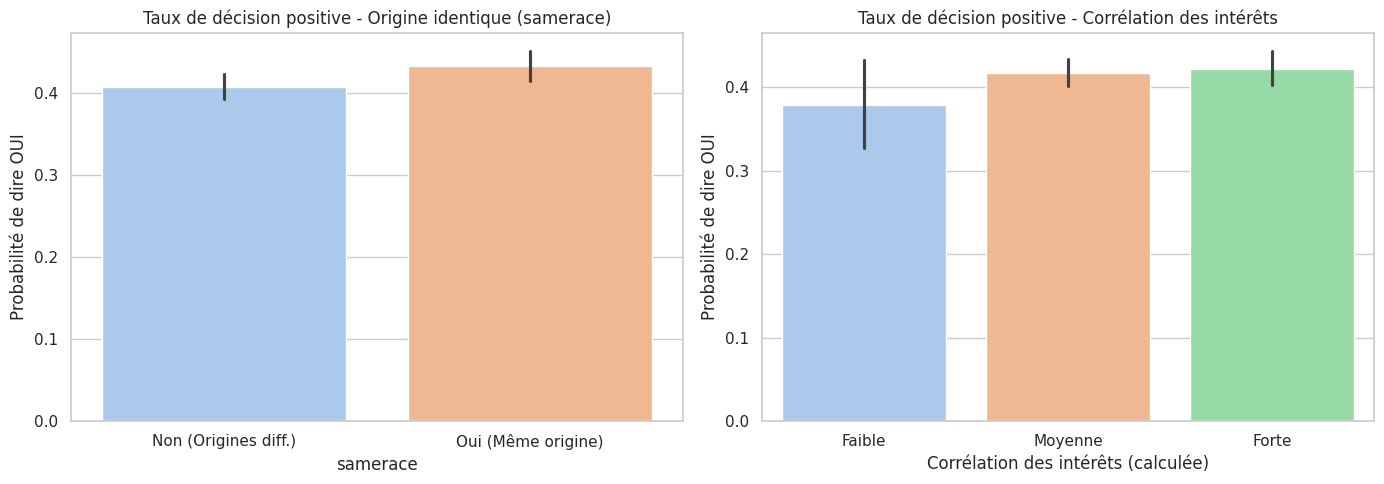

In [9]:
# Corrélation des intérêts (int_corr) par rapport à la décision
df['int_corr_bin'] = pd.cut(df['int_corr'], bins=[-1, -0.33, 0.33, 1.0], labels=['Faible', 'Moyenne', 'Forte'])

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
sns.barplot(data=df.dropna(subset=['samerace', 'dec']), x='samerace', y='dec', palette='pastel')
plt.title("Taux de décision positive - Origine identique (samerace)")
plt.xticks([0, 1], ['Non (Origines diff.)', 'Oui (Même origine)'])
plt.ylabel("Probabilité de dire OUI")

plt.subplot(1, 2, 2)
sns.barplot(data=df.dropna(subset=['int_corr_bin', 'dec']), x='int_corr_bin', y='dec', palette='pastel')
plt.title("Taux de décision positive - Corrélation des intérêts")
plt.xlabel("Corrélation des intérêts (calculée)")
plt.ylabel("Probabilité de dire OUI")

plt.tight_layout()
plt.show()

**Interprétation :**
*   Avoir la **même origine** semble augmenter très légèrement la chance d'obtenir un "oui".
*   Cependant, étonnamment, une forte corrélation d'intérêts (int_corr) n'augmente *pas* significativement la probabilité d'avoir un "oui" par rapport à une faible corrélation.
*   Conclusion : Le fait de partager le même profil racial semble peser marginalement plus dans l'algorithme inconscient d'un second rendez-vous que d'avoir répondu aux mêmes hobbies dans le questionnaire.

## 4. Les gens peuvent-ils prédire leur propre valeur perçue sur le marché des rencontres ?
On observe la note qu'ils se donnent en attractivité (attr3_1) versus la note moyenne qu'ils reçoivent des autres (attr_o).

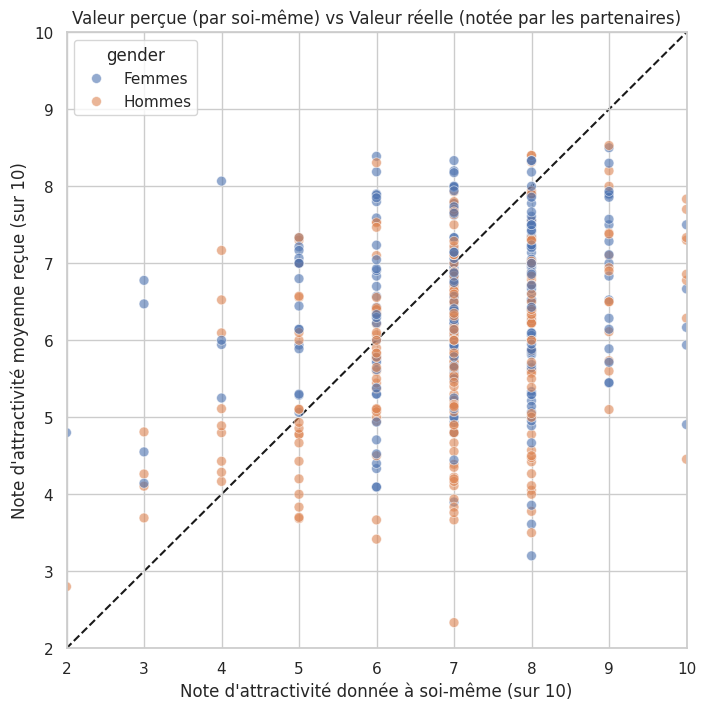

,Genre,Corrélation (Soi-même vs Autres)
0,Femmes,0.178121
1,Hommes,0.364119


In [10]:
df_self = df[['iid', 'gender', 'attr3_1']].drop_duplicates()
df_others = df.groupby('iid')['attr_o'].mean().reset_index()

df_val = pd.merge(df_self, df_others, on='iid').dropna()
df_val['gender'] = df_val['gender'].map({0: 'Femmes', 1: 'Hommes'})

plt.figure(figsize=(8, 8))
sns.scatterplot(data=df_val, x='attr3_1', y='attr_o', hue='gender', alpha=0.6, s=50)
plt.plot([0, 10], [0, 10], 'k--', zorder=0) # Ligne y=x
plt.title("Valeur perçue (par soi-même) vs Valeur réelle (notée par les partenaires)")
plt.xlabel("Note d'attractivité donnée à soi-même (sur 10)")
plt.ylabel("Note d'attractivité moyenne reçue (sur 10)")
plt.xlim(2, 10)
plt.ylim(2, 10)
plt.show()

corr_femmes = df_val[df_val['gender']=='Femmes']['attr3_1'].corr(df_val[df_val['gender']=='Femmes']['attr_o'])
corr_hommes = df_val[df_val['gender']=='Hommes']['attr3_1'].corr(df_val[df_val['gender']=='Hommes']['attr_o'])

display(pd.DataFrame({
    'Genre': ['Femmes', 'Hommes'],
    'Corrélation (Soi-même vs Autres)': [corr_femmes, corr_hommes]
}))

**Interprétation :**
*   La majorité des points se trouvent **sous la ligne pointillée noire**, ce qui signifie que la plupart des individus (hommes comme femmes) **surestiment leur propre niveau d'attractivité** par rapport à l'évaluation des autres (i.e., ils se donnent un 8, mais reçoivent une moyenne de 6).
*   Les corrélations entre l'auto-évaluation et l'évaluation reçue sont extrêmement faibles (autour de 0.2). Cela indique que les gens ne sont globalement **pas capables de prédire précisément** leur propre valeur sur le marché.

## 5. Pour obtenir un second rendez-vous, vaut-il mieux être le premier du speed dating ou le dernier ?
Regardons le taux de de décisions positives (dec) en fonction de la position (order) chronologique de la rencontre dans la soirée.

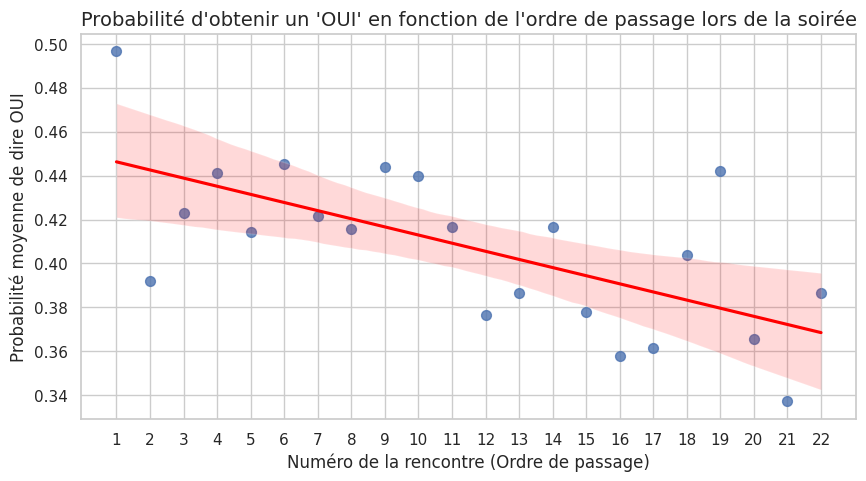

In [11]:
df_order = df.groupby('order')['dec'].mean().reset_index()

plt.figure(figsize=(10, 5))
sns.regplot(data=df_order, x='order', y='dec', scatter_kws={'s': 50}, line_kws={'color': 'red'})
plt.title("Probabilité d'obtenir un 'OUI' en fonction de l'ordre de passage lors de la soirée", fontsize=14)
plt.xlabel("Numéro de la rencontre (Ordre de passage)")
plt.ylabel("Probabilité moyenne de dire OUI")
plt.xticks(np.arange(1, 23))
plt.show()

**Interprétation :**
*   La ligne de tendance (rouge) montre une **très légère corrélation négative** : plus on rencontre de partenaires dans la soirée, plus la probabilité de dire "OUI" baisse légèrement (phénomène de fatigue liée au choix, ou "choice overload").
*   Il est donc statistiquement **préférable d'être parmi les premiers rendez-vous** de la soirée de quelqu'un. L'attention et la tolérance sont plus élevées en début de processus qu'à la fin.

---
## Conclusion Globale
- **Le physique domine dans la décision réelle**, malgré ce qu'affirment les candidates féminines.
- Rédiger l'algorithme de matching basé sur de simples "intérêts partagés" n'aura pas les résultats escomptés; le succès passe souvent par la première impression et l'attractivité physique.
- La **fatigue décisionnelle** rend les derniers rendez-vous plus difficiles que les premiers.